In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from hamiltonian.z2ham import hamiltonian, sum_star_operators, transverse_field

# Enable 64-bit precision
jax.config.update("jax_enable_x64", True)

print("JAX version:", jax.__version__)
print("NumPy version:", np.__version__)


JAX version: 0.4.23
NumPy version: 1.24.4


In [7]:
# System parameters
Lx = 2
Ly = 1
j_a = -1.0  # Star operator coupling (fixed)

# Build operators once (they're independent of h)
print(f"Building operators for {Lx}x{Ly} lattice...")
star_ops = sum_star_operators(Lx, Ly)
trans_ops = transverse_field(Lx, Ly)
print(f"✓ Operators built. Matrix size: {star_ops.shape}")


Building operators for 2x1 lattice...
✓ Operators built. Matrix size: (16, 16)


In [8]:
# Compute spectral gap at h = -1.0 exactly
print("\n" + "=" * 70)
print("SPECTRAL GAP AT h = -1.0")
print("=" * 70)

h_target = -1.5
H_target = hamiltonian(j_a=j_a, h=h_target, star_ops=star_ops, trans_ops=trans_ops)
eigenvalues_target = jnp.linalg.eigvalsh(H_target)

ground_energy = float(eigenvalues_target[0])
first_excited_energy = float(eigenvalues_target[1]) if len(eigenvalues_target) > 1 else ground_energy
spectral_gap = first_excited_energy - ground_energy

print(f"\nAt h = {h_target:.6f}:")
print(f"  Ground state energy (E₀): {ground_energy:.10f}")
print(f"  First excited energy (E₁): {first_excited_energy:.10f}")
print(f"  Spectral gap (E₁ - E₀): {spectral_gap:.10f}")
print(f"  Spectral gap (scientific notation): {spectral_gap:.6e}")

# Compute full spectrum for a range of h values
h_values = jnp.linspace(-2.0, 0, 50)
n_states = star_ops.shape[0]  # Total number of states

print(f"\n" + "=" * 70)
print(f"Computing spectrum for {len(h_values)} h values...")
print(f"System size: {Lx}x{Ly}, Hilbert space dimension: {n_states}")

# Store eigenvalues for each h
all_eigenvalues = []
ground_energies = []
first_excited = []
spectral_gaps = []

for i, h in enumerate(h_values):
    H = hamiltonian(j_a=j_a, h=h, star_ops=star_ops, trans_ops=trans_ops)
    eigenvalues = jnp.linalg.eigvalsh(H)
    
    all_eigenvalues.append(np.array(eigenvalues))
    ground_energies.append(float(eigenvalues[0]))
    
    if len(eigenvalues) > 1:
        first_excited.append(float(eigenvalues[1]))
        gap = float(eigenvalues[1] - eigenvalues[0])
        spectral_gaps.append(gap)
    else:
        first_excited.append(float(eigenvalues[0]))
        spectral_gaps.append(0.0)
    
    if (i + 1) % 10 == 0:
        print(f"  Progress: {i+1}/{len(h_values)} - h={float(h):.3f}, E0={ground_energies[-1]:.6f}, gap={spectral_gaps[-1]:.6f}")

all_eigenvalues = np.array(all_eigenvalues)
ground_energies = np.array(ground_energies)
first_excited = np.array(first_excited)
spectral_gaps = np.array(spectral_gaps)

print(f"\n✓ Spectrum computation complete!")


SPECTRAL GAP AT h = -1.0

At h = -1.500000:
  Ground state energy (E₀): -6.2246350259
  First excited energy (E₁): -3.7400843317
  Spectral gap (E₁ - E₀): 2.4845506942
  Spectral gap (scientific notation): 2.484551e+00

Computing spectrum for 50 h values...
System size: 2x1, Hilbert space dimension: 16
  Progress: 10/50 - h=-1.633, E0=-6.736689, gap=2.775813
  Progress: 20/50 - h=-1.224, E0=-5.174325, gap=1.875146
  Progress: 30/50 - h=-0.816, E0=-3.684239, gap=0.977722
  Progress: 40/50 - h=-0.408, E0=-2.449294, gap=0.218664
  Progress: 50/50 - h=0.000, E0=-2.000000, gap=0.000000

✓ Spectrum computation complete!


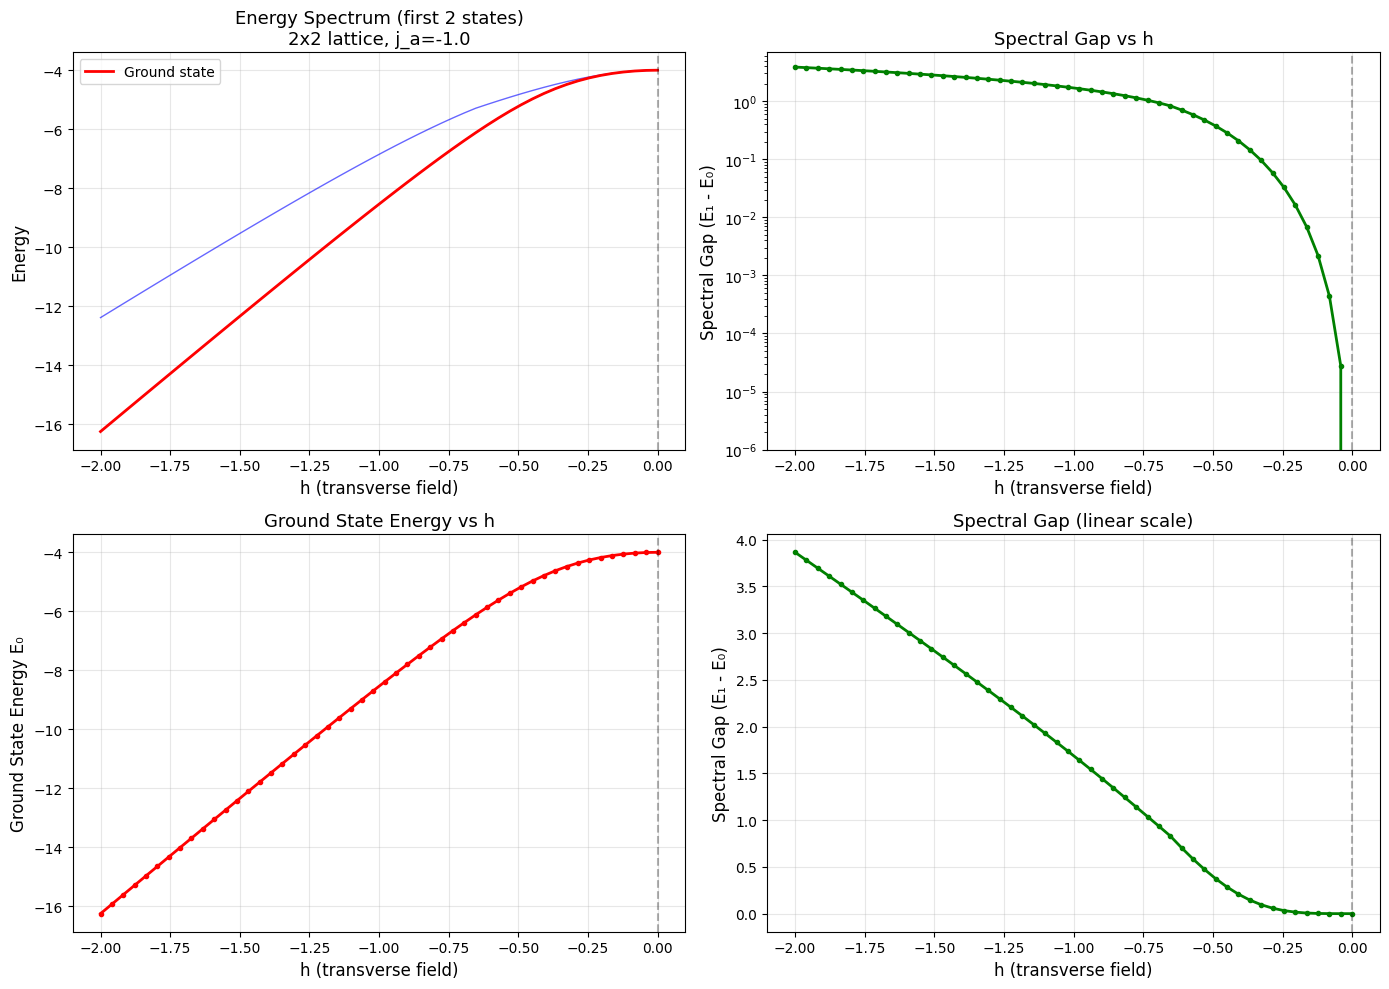

In [5]:
# Plot 1: Full spectrum (first few eigenvalues)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1a: First 2 eigenvalues
ax = axes[0, 0]
for i in range(min(2, n_states)):
    ax.plot(h_values, all_eigenvalues[:, i], 'b-', alpha=0.6, linewidth=1)
ax.plot(h_values, ground_energies, 'r-', linewidth=2, label='Ground state')
ax.set_xlabel('h (transverse field)', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title(f'Energy Spectrum (first 2 states)\n{Lx}x{Ly} lattice, j_a={j_a}', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend()
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Plot 1b: Spectral gap
ax = axes[0, 1]
ax.plot(h_values, spectral_gaps, 'g-', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('h (transverse field)', fontsize=12)
ax.set_ylabel('Spectral Gap (E₁ - E₀)', fontsize=12)
ax.set_title('Spectral Gap vs h', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.set_yscale('log')
ax.set_ylim(bottom=1e-6)

# Plot 1c: Ground state energy
ax = axes[1, 0]
ax.plot(h_values, ground_energies, 'r-', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('h (transverse field)', fontsize=12)
ax.set_ylabel('Ground State Energy E₀', fontsize=12)
ax.set_title('Ground State Energy vs h', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Plot 1d: Gap on linear scale (zoomed)
ax = axes[1, 1]
ax.plot(h_values, spectral_gaps, 'g-', linewidth=2, marker='o', markersize=3)
ax.set_xlabel('h (transverse field)', fontsize=12)
ax.set_ylabel('Spectral Gap (E₁ - E₀)', fontsize=12)
ax.set_title('Spectral Gap (linear scale)', fontsize=13)
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/z2gauge_spectrum_analysis.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [18]:

# Detailed analysis: Find minimum gap and critical points
min_gap_idx = np.argmin(spectral_gaps)
min_gap_h = float(h_values[min_gap_idx])
min_gap_value = spectral_gaps[min_gap_idx]

print("=" * 70)
print("SPECTRAL GAP ANALYSIS")
print("=" * 70)
print(f"Minimum gap: {min_gap_value:.8f}")
print(f"Location: h = {min_gap_h:.6f}")
print(f"Ground state energy at min gap: {ground_energies[min_gap_idx]:.6f}")
print(f"First excited energy at min gap: {first_excited[min_gap_idx]:.6f}")
print()

# Check for gap closure (within numerical precision)
gap_threshold = 1e-6
closed_gap_indices = np.where(spectral_gaps < gap_threshold)[0]
if len(closed_gap_indices) > 0:
    print(f"⚠️  Gap closes (gap < {gap_threshold}) at:")
    for idx in closed_gap_indices[:5]:  # Show first 5
        print(f"   h = {float(h_values[idx]):.6f}, gap = {spectral_gaps[idx]:.8f}")
    if len(closed_gap_indices) > 5:
        print(f"   ... and {len(closed_gap_indices) - 5} more points")
else:
    print(f"✓ Gap remains finite (min gap = {min_gap_value:.8f})")

print()
print("Gap statistics:")
print(f"  Mean gap: {np.mean(spectral_gaps):.8f}")
print(f"  Std gap: {np.std(spectral_gaps):.8f}")
print(f"  Max gap: {np.max(spectral_gaps):.8f}")
print(f"  Min gap: {np.min(spectral_gaps):.8f}")

SPECTRAL GAP ANALYSIS
Minimum gap: 0.00000000
Location: h = 0.000000
Ground state energy at min gap: -4.000000
First excited energy at min gap: -4.000000

⚠️  Gap closes (gap < 1e-06) at:
   h = 0.000000, gap = 0.00000000

Gap statistics:
  Mean gap: 1.69338873
  Std gap: 1.27675766
  Max gap: 3.86420518
  Min gap: 0.00000000


In [ ]:
# Analyze degeneracy structure
print("\n" + "=" * 70)
print("DEGENERACY ANALYSIS")
print("=" * 70)

# Check degeneracy at a few key points
key_h_indices = [0, len(h_values)//4, len(h_values)//2, 3*len(h_values)//4, len(h_values)-1]
key_h_values = [float(h_values[i]) for i in key_h_indices]

for idx in key_h_indices:
    h_val = float(h_values[idx])
    evals = all_eigenvalues[idx]
    
    # Count degeneracies (within numerical tolerance)
    tol = 1e-8
    unique_energies, counts = np.unique(np.round(evals / tol) * tol, return_counts=True)
    
    degeneracies = counts[counts > 1]
    max_degeneracy = np.max(counts) if len(counts) > 0 else 1
    
    print(f"\nh = {h_val:+.4f}:")
    print(f"  Ground state energy: {evals[0]:.8f}")
    print(f"  Spectral gap: {spectral_gaps[idx]:.8f}")
    print(f"  Maximum degeneracy: {max_degeneracy}")
    if len(degeneracies) > 0:
        print(f"  Degenerate levels: {len(degeneracies)} (multiplicities: {degeneracies[:5]})")
    else:
        print(f"  No degeneracies detected (within tolerance {tol})")



DEGENERACY ANALYSIS

h = -2.0000:
  Ground state energy: -16.25576071
  Spectral gap: 3.86420518
  Maximum degeneracy: 48
  Degenerate levels: 23 (multiplicities: [8 8 4 6 8])

h = -1.5102:
  Ground state energy: -12.42590025
  Spectral gap: 2.83158967
  Maximum degeneracy: 48
  Degenerate levels: 25 (multiplicities: [8 8 4 6 8])

h = -0.9796:
  Ground state energy: -8.39281862
  Spectral gap: 1.64062483
  Maximum degeneracy: 48
  Degenerate levels: 25 (multiplicities: [8 8 4 8 2])

h = -0.4898:
  Ground state energy: -5.17342531
  Spectral gap: 0.37371092
  Maximum degeneracy: 48
  Degenerate levels: 25 (multiplicities: [8 8 4 8 2])

h = +0.0000:
  Ground state energy: -4.00000000
  Spectral gap: 0.00000000
  Maximum degeneracy: 192
  Degenerate levels: 3 (multiplicities: [ 32 192  32])


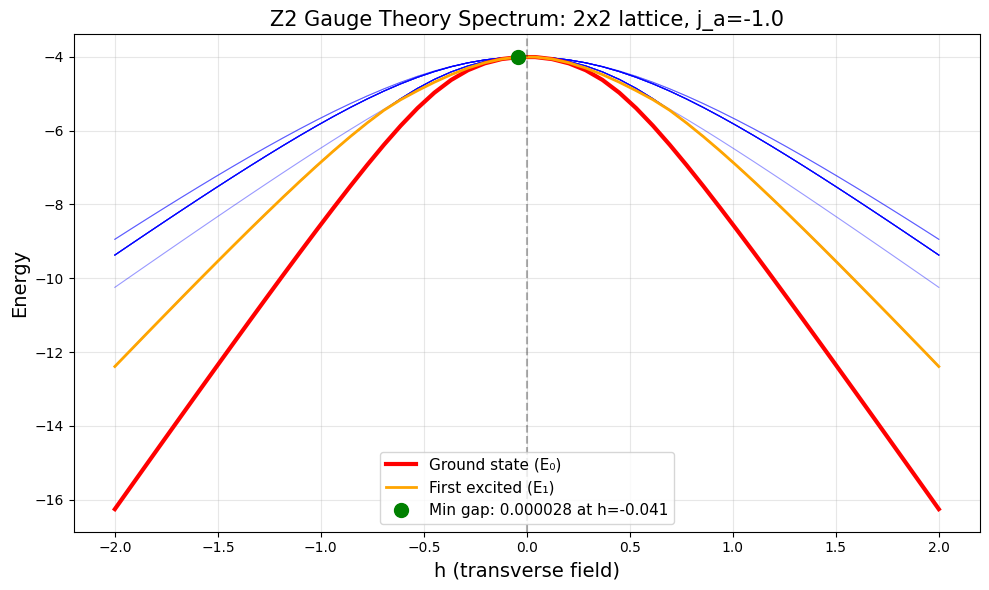

In [8]:
# Plot degeneracy structure
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot all eigenvalues with color coding for degeneracy
for i in range(min(20, n_states)):  # Plot first 20 states
    ax.plot(h_values, all_eigenvalues[:, i], 'b-', alpha=0.4, linewidth=0.8)

# Highlight ground state and first excited
ax.plot(h_values, ground_energies, 'r-', linewidth=3, label='Ground state (E₀)')
ax.plot(h_values, first_excited, 'orange', linewidth=2, label='First excited (E₁)')

# Mark minimum gap
ax.plot(min_gap_h, ground_energies[min_gap_idx], 'go', markersize=10, 
        label=f'Min gap: {min_gap_value:.6f} at h={min_gap_h:.3f}')

ax.set_xlabel('h (transverse field)', fontsize=14)
ax.set_ylabel('Energy', fontsize=14)
ax.set_title(f'Z2 Gauge Theory Spectrum: {Lx}x{Ly} lattice, j_a={j_a}', fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3, label='h=0')

plt.tight_layout()
plt.savefig('../figures/z2gauge_full_spectrum.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [20]:
# Analyze ground state degeneracy
print("\n" + "=" * 70)
print("GROUND STATE DEGENERACY ANALYSIS")
print("=" * 70)

tol = 1e-8
ground_state_degeneracies = []
ground_state_energies = []

for idx in range(len(h_values)):
    h_val = float(h_values[idx])
    evals = all_eigenvalues[idx]
    ground_energy = evals[0]
    
    # Count how many states have the same energy as the ground state (within tolerance)
    ground_degeneracy = np.sum(np.abs(evals - ground_energy) < tol)
    
    ground_state_degeneracies.append(ground_degeneracy)
    ground_state_energies.append(ground_energy)

ground_state_degeneracies = np.array(ground_state_degeneracies)
ground_state_energies = np.array(ground_state_energies)

# Find maximum ground state degeneracy
max_gs_degen_idx = np.argmax(ground_state_degeneracies)
max_gs_degeneracy = ground_state_degeneracies[max_gs_degen_idx]
max_gs_degen_h = float(h_values[max_gs_degen_idx])
max_gs_degen_energy = ground_state_energies[max_gs_degen_idx]

print(f"\nGROUND STATE DEGENERACY STATISTICS:")
print(f"  Maximum ground state degeneracy: {max_gs_degeneracy}")
print(f"  Location: h = {max_gs_degen_h:.6f}")
print(f"  Ground state energy at max degeneracy: {max_gs_degen_energy:.8f}")
print(f"  Mean ground state degeneracy: {np.mean(ground_state_degeneracies):.2f}")
print(f"  Minimum ground state degeneracy: {np.min(ground_state_degeneracies)}")
print(f"  Number of h values with degenerate ground state: {np.sum(ground_state_degeneracies > 1)}")
print()

# Show ground state degeneracy at key points
print("Ground state degeneracy at key h values:")
print(f"{'h':>10} | {'E₀':>15} | {'GS Degeneracy':>15}")
print("-" * 45)
key_h_indices = [0, len(h_values)//4, len(h_values)//2, 3*len(h_values)//4, len(h_values)-1]
for idx in key_h_indices:
    h_val = float(h_values[idx])
    e0 = ground_state_energies[idx]
    gs_degen = ground_state_degeneracies[idx]
    print(f"{h_val:>10.4f} | {e0:>15.8f} | {gs_degen:>15}")

# Check if ground state is degenerate at h = -1.5 (the value used in active phase discovery)
h_target = -1.5
h_closest_idx = np.argmin(np.abs(h_values - h_target))
h_closest = float(h_values[h_closest_idx])
gs_degen_at_target = ground_state_degeneracies[h_closest_idx]
e0_at_target = ground_state_energies[h_closest_idx]

print(f"\nAt h ≈ {h_closest:.6f} (closest to h = -1.5):")
print(f"  Ground state energy: {e0_at_target:.8f}")
print(f"  Ground state degeneracy: {gs_degen_at_target}")
if gs_degen_at_target > 1:
    print(f"  ⚠️  Ground state is DEGENERATE (multiplicity = {gs_degen_at_target})")
else:
    print(f"  ✓ Ground state is NON-DEGENERATE")



GROUND STATE DEGENERACY ANALYSIS

GROUND STATE DEGENERACY STATISTICS:
  Maximum ground state degeneracy: 32
  Location: h = 0.000000
  Ground state energy at max degeneracy: -4.00000000
  Mean ground state degeneracy: 1.62
  Minimum ground state degeneracy: 1
  Number of h values with degenerate ground state: 1

Ground state degeneracy at key h values:
         h |              E₀ |   GS Degeneracy
---------------------------------------------
   -2.0000 |    -16.25576071 |               1
   -1.5102 |    -12.42590025 |               1
   -0.9796 |     -8.39281862 |               1
   -0.4898 |     -5.17342531 |               1
    0.0000 |     -4.00000000 |              32

At h ≈ -1.510204 (closest to h = -1.5):
  Ground state energy: -12.42590025
  Ground state degeneracy: 1
  ✓ Ground state is NON-DEGENERATE


In [ ]:
# Plot ground state degeneracy vs h
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(h_values, ground_state_degeneracies, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Non-degenerate (degeneracy = 1)')
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=-1.5, color='g', linestyle='--', alpha=0.5, label='h = -1.5 (active phase)')

# Mark maximum degeneracy point
ax.plot(max_gs_degen_h, max_gs_degeneracy, 'ro', markersize=10, 
        label=f'Max GS degeneracy: {max_gs_degeneracy} at h={max_gs_degen_h:.3f}')

ax.set_xlabel('h (transverse field)', fontsize=14)
ax.set_ylabel('Ground State Degeneracy', fontsize=14)
ax.set_title(f'Ground State Degeneracy vs h\n{Lx}x{Ly} lattice, j_a={j_a}', fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('../figures/z2gauge_ground_state_degeneracy.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [21]:
# Detailed analysis near h = 0
print("\n" + "=" * 70)
print("GROUND STATE DEGENERACY ANALYSIS NEAR h = 0")
print("=" * 70)

# Compute spectrum with higher resolution near h = 0
h_range_near_zero = 0.5  # Range around h=0 to analyze
h_resolution = 0.01  # Resolution for fine-grained analysis
h_values_fine = jnp.linspace(-h_range_near_zero, h_range_near_zero, 
                             int(2 * h_range_near_zero / h_resolution) + 1)

print(f"Computing spectrum with high resolution near h=0...")
print(f"Range: [{float(h_values_fine[0]):.4f}, {float(h_values_fine[-1]):.4f}]")
print(f"Number of points: {len(h_values_fine)}")

gs_degeneracies_fine = []
gs_energies_fine = []
spectral_gaps_fine = []

for i, h in enumerate(h_values_fine):
    H = hamiltonian(j_a=j_a, h=h, star_ops=star_ops, trans_ops=trans_ops)
    eigenvalues = jnp.linalg.eigvalsh(H)
    
    ground_energy = float(eigenvalues[0])
    tol = 1e-8
    ground_degeneracy = np.sum(np.abs(eigenvalues - ground_energy) < tol)
    
    gs_degeneracies_fine.append(ground_degeneracy)
    gs_energies_fine.append(ground_energy)
    
    if len(eigenvalues) > 1:
        gap = float(eigenvalues[1] - eigenvalues[0])
        spectral_gaps_fine.append(gap)
    else:
        spectral_gaps_fine.append(0.0)
    
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(h_values_fine)} - h={float(h):.4f}, GS_degen={ground_degeneracy}")

gs_degeneracies_fine = np.array(gs_degeneracies_fine)
gs_energies_fine = np.array(gs_energies_fine)
spectral_gaps_fine = np.array(spectral_gaps_fine)

print(f"\n✓ Fine-grained computation complete!")



GROUND STATE DEGENERACY ANALYSIS NEAR h = 0
Computing spectrum with high resolution near h=0...
Range: [-0.5000, 0.5000]
Number of points: 101
  Progress: 20/101 - h=-0.3100, GS_degen=1
  Progress: 40/101 - h=-0.1100, GS_degen=1
  Progress: 60/101 - h=0.0900, GS_degen=1
  Progress: 80/101 - h=0.2900, GS_degen=1
  Progress: 100/101 - h=0.4900, GS_degen=1

✓ Fine-grained computation complete!


In [24]:
# Analyze ground state degeneracy near h=0
print("\n" + "=" * 70)
print("GROUND STATE DEGENERACY NEAR h = 0 (DETAILED)")
print("=" * 70)

# Find h=0 exactly or closest point
h_zero_idx = np.argmin(np.abs(h_values_fine))
h_zero_val = float(h_values_fine[h_zero_idx])
gs_degen_at_zero = gs_degeneracies_fine[h_zero_idx]
e0_at_zero = gs_energies_fine[h_zero_idx]
gap_at_zero = spectral_gaps_fine[h_zero_idx]

print(f"\nAt h = {h_zero_val:.6f} (closest to 0):")
print(f"  Ground state energy: {e0_at_zero:.8f}")
print(f"  Ground state degeneracy: {gs_degen_at_zero}")
print(f"  Spectral gap: {gap_at_zero:.8f}")
if gs_degen_at_zero > 1:
    print(f"  ⚠️  Ground state is DEGENERATE (multiplicity = {gs_degen_at_zero})")
else:
    print(f"  ✓ Ground state is NON-DEGENERATE")

# Check a range around h=0
print(f"\nGround state degeneracy in range [-0.1, 0.1]:")
print(f"{'h':>10} | {'E₀':>15} | {'GS Degeneracy':>15} | {'Gap':>15}")
print("-" * 65)

mask = np.abs(h_values_fine) <= 0.1
indices_near_zero = np.where(mask)[0]

# Show every 5th point to avoid too much output
step = max(1, len(indices_near_zero) // 20)
for idx in indices_near_zero[::step]:
    h_val = float(h_values_fine[idx])
    e0 = gs_energies_fine[idx]
    degen = gs_degeneracies_fine[idx]
    gap = spectral_gaps_fine[idx]
    print(f"{h_val:>10.4f} | {e0:>15.8f} | {degen:>15} | {gap:>15.8f}")

# Statistics near h=0
print(f"\nStatistics in range [-0.1, 0.1]:")
print(f"  Mean ground state degeneracy: {np.mean(gs_degeneracies_fine[mask]):.2f}")
print(f"  Max ground state degeneracy: {np.max(gs_degeneracies_fine[mask])}")
print(f"  Min ground state degeneracy: {np.min(gs_degeneracies_fine[mask])}")
print(f"  Number of points with degenerate GS: {np.sum(gs_degeneracies_fine[mask] > 1)}")
print(f"  Number of points with non-degenerate GS: {np.sum(gs_degeneracies_fine[mask] == 1)}")



GROUND STATE DEGENERACY NEAR h = 0 (DETAILED)

At h = 0.000000 (closest to 0):
  Ground state energy: -4.00000000
  Ground state degeneracy: 32
  Spectral gap: 0.00000000
  ⚠️  Ground state is DEGENERATE (multiplicity = 32)

Ground state degeneracy in range [-0.1, 0.1]:
         h |              E₀ |   GS Degeneracy |             Gap
-----------------------------------------------------------------
   -0.1000 |     -4.04059370 |               1 |      0.00098589
   -0.0900 |     -4.03279034 |               1 |      0.00064861
   -0.0800 |     -4.02584414 |               1 |      0.00040591
   -0.0700 |     -4.01974334 |               1 |      0.00023845
   -0.0600 |     -4.01447747 |               1 |      0.00012895
   -0.0500 |     -4.01003741 |               1 |      0.00006228
   -0.0400 |     -4.00641534 |               1 |      0.00002554
   -0.0300 |     -4.00360486 |               1 |      0.00000809
   -0.0200 |     -4.00160096 |               1 |      0.00000160
   -0.0100 |

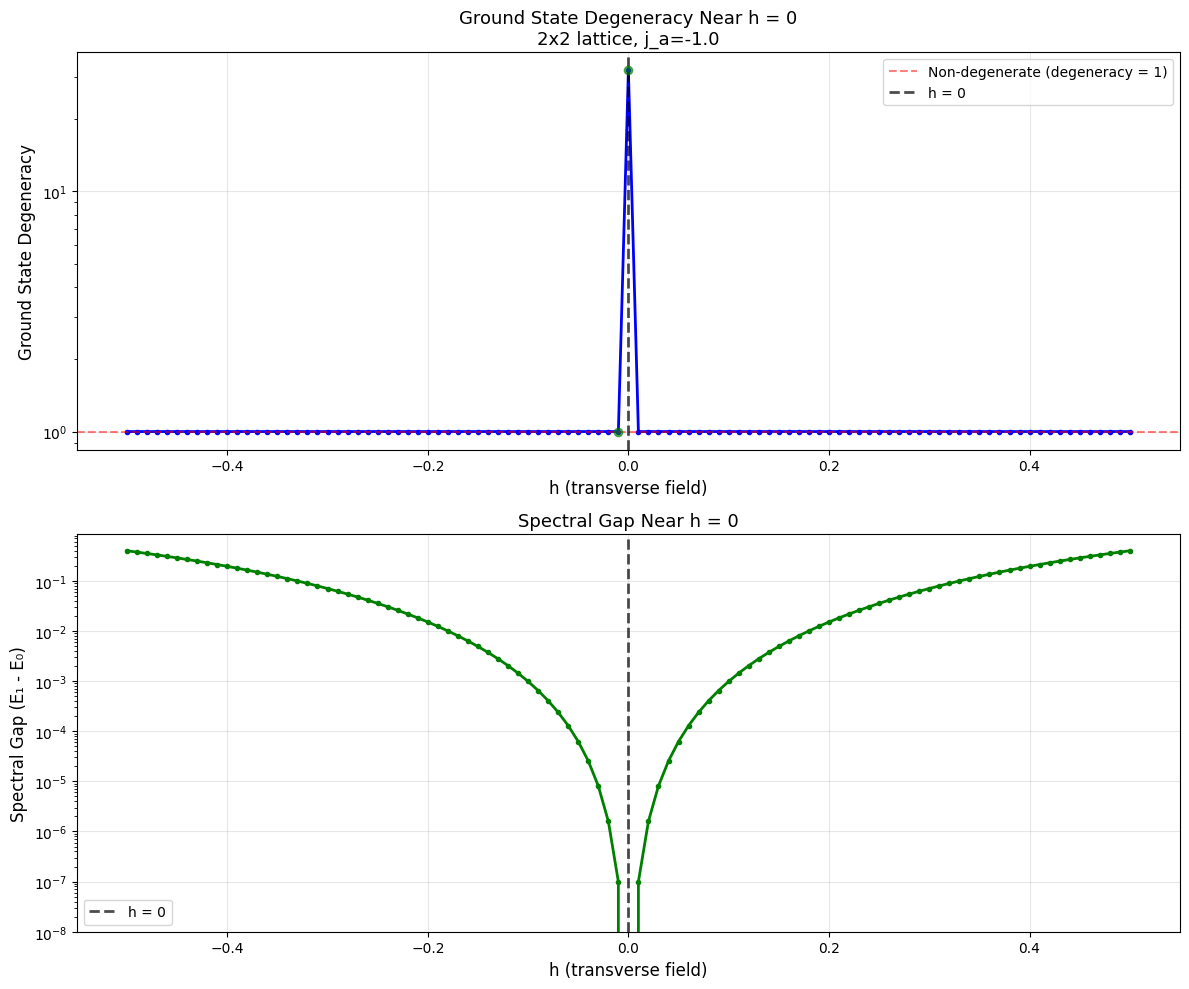

In [25]:
# Plot ground state degeneracy near h=0
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Ground state degeneracy
ax = axes[0]
ax.plot(h_values_fine, gs_degeneracies_fine, 'b-', linewidth=2, marker='o', markersize=3)
ax.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Non-degenerate (degeneracy = 1)')
ax.axvline(x=0, color='k', linestyle='--', linewidth=2, alpha=0.7, label='h = 0')

# Mark points where degeneracy changes
degen_changes = np.where(np.diff(gs_degeneracies_fine) != 0)[0]
if len(degen_changes) > 0:
    for change_idx in degen_changes[::max(1, len(degen_changes)//10)]:  # Show subset
        h_change = float(h_values_fine[change_idx])
        degen_before = gs_degeneracies_fine[change_idx]
        ax.plot(h_change, degen_before, 'go', markersize=6, alpha=0.6)

ax.set_xlabel('h (transverse field)', fontsize=12)
ax.set_ylabel('Ground State Degeneracy', fontsize=12)
ax.set_title(f'Ground State Degeneracy Near h = 0\n{Lx}x{Ly} lattice, j_a={j_a}', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_yscale('log')

# Plot 2: Spectral gap near h=0
ax = axes[1]
ax.plot(h_values_fine, spectral_gaps_fine, 'g-', linewidth=2, marker='o', markersize=3)
ax.axvline(x=0, color='k', linestyle='--', linewidth=2, alpha=0.7, label='h = 0')

ax.set_xlabel('h (transverse field)', fontsize=12)
ax.set_ylabel('Spectral Gap (E₁ - E₀)', fontsize=12)
ax.set_title('Spectral Gap Near h = 0', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.set_ylim(bottom=1e-8)

plt.tight_layout()
plt.savefig('../figures/z2gauge_gs_degeneracy_near_zero.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [26]:
# Check if there's a transition at h=0
print("\n" + "=" * 70)
print("TRANSITION ANALYSIS AT h = 0")
print("=" * 70)

# Check left and right of h=0
h_small = 0.01
h_left_idx = np.argmin(np.abs(h_values_fine + h_small))
h_right_idx = np.argmin(np.abs(h_values_fine - h_small))

h_left = float(h_values_fine[h_left_idx])
h_right = float(h_values_fine[h_right_idx])

print(f"\nComparison:")
print(f"{'Parameter':<25} | {'h < 0':<20} | {'h = 0':<20} | {'h > 0':<20}")
print("-" * 75)
print(f"{'h value':<25} | {h_left:<20.6f} | {h_zero_val:<20.6f} | {h_right:<20.6f}")
print(f"{'Ground state energy':<25} | {gs_energies_fine[h_left_idx]:<20.8f} | {e0_at_zero:<20.8f} | {gs_energies_fine[h_right_idx]:<20.8f}")
print(f"{'GS degeneracy':<25} | {gs_degeneracies_fine[h_left_idx]:<20} | {gs_degen_at_zero:<20} | {gs_degeneracies_fine[h_right_idx]:<20}")
print(f"{'Spectral gap':<25} | {spectral_gaps_fine[h_left_idx]:<20.8f} | {gap_at_zero:<20.8f} | {spectral_gaps_fine[h_right_idx]:<20.8f}")

# Check if degeneracy is symmetric
if abs(gs_degeneracies_fine[h_left_idx] - gs_degeneracies_fine[h_right_idx]) < 1e-6:
    print(f"\n✓ Ground state degeneracy appears symmetric around h=0")
else:
    print(f"\n⚠️  Ground state degeneracy is NOT symmetric around h=0")
    print(f"   Left side (h={h_left:.4f}): degeneracy = {gs_degeneracies_fine[h_left_idx]}")
    print(f"   Right side (h={h_right:.4f}): degeneracy = {gs_degeneracies_fine[h_right_idx]}")

# Check if gap closes at h=0
if gap_at_zero < 1e-6:
    print(f"\n⚠️  Spectral gap CLOSES at h=0 (gap = {gap_at_zero:.2e})")
    print(f"   This suggests a phase transition or critical point")
else:
    print(f"\n✓ Spectral gap remains finite at h=0 (gap = {gap_at_zero:.8f})")



TRANSITION ANALYSIS AT h = 0

Comparison:
Parameter                 | h < 0                | h = 0                | h > 0               
---------------------------------------------------------------------------
h value                   | -0.010000            | 0.000000             | 0.010000            
Ground state energy       | -4.00040006          | -4.00000000          | -4.00040006         
GS degeneracy             | 1                    | 32                   | 1                   
Spectral gap              | 0.00000010           | 0.00000000           | 0.00000010          

✓ Ground state degeneracy appears symmetric around h=0

⚠️  Spectral gap CLOSES at h=0 (gap = 0.00e+00)
   This suggests a phase transition or critical point


In [28]:
# Compute full spectrum (first 32 eigenvalues) near h=0
print("\n" + "=" * 70)
print("COMPUTING LOWEST 32 EIGENVALUES NEAR h = 0")
print("=" * 70)

n_eigenvalues_to_plot = 32
all_eigenvalues_fine = []

print(f"Computing lowest {n_eigenvalues_to_plot} eigenvalues for {len(h_values_fine)} h values...")

for i, h in enumerate(h_values_fine):
    H = hamiltonian(j_a=j_a, h=h, star_ops=star_ops, trans_ops=trans_ops)
    eigenvalues = jnp.linalg.eigvalsh(H)
    
    # Store only the first n_eigenvalues_to_plot eigenvalues
    eigenvalues_subset = eigenvalues[:min(n_eigenvalues_to_plot, len(eigenvalues))]
    all_eigenvalues_fine.append(np.array(eigenvalues_subset))
    
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i+1}/{len(h_values_fine)} - h={float(h):.4f}")

all_eigenvalues_fine = np.array(all_eigenvalues_fine)
print(f"\n✓ Spectrum computation complete!")
print(f"Shape: {all_eigenvalues_fine.shape} (h_values x eigenvalues)")



COMPUTING LOWEST 32 EIGENVALUES NEAR h = 0
Computing lowest 32 eigenvalues for 101 h values...
  Progress: 20/101 - h=-0.3100
  Progress: 40/101 - h=-0.1100
  Progress: 60/101 - h=0.0900
  Progress: 80/101 - h=0.2900
  Progress: 100/101 - h=0.4900

✓ Spectrum computation complete!
Shape: (101, 32) (h_values x eigenvalues)


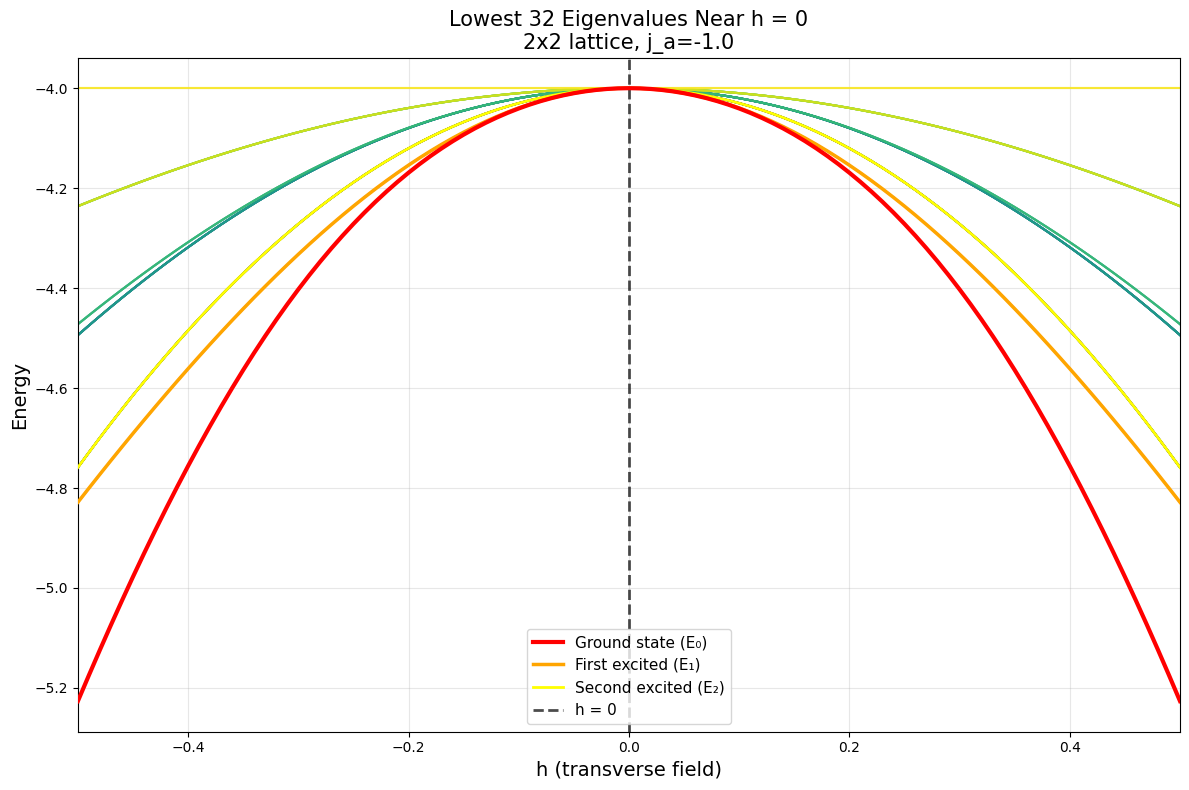

In [29]:
# Plot lowest 32 eigenvalues near h=0
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot all 32 eigenvalues
colors = plt.cm.viridis(np.linspace(0, 1, n_eigenvalues_to_plot))
for i in range(n_eigenvalues_to_plot):
    ax.plot(h_values_fine, all_eigenvalues_fine[:, i], 
            color=colors[i], linewidth=1.5, alpha=0.7)

# Highlight ground state and first few excited states
ax.plot(h_values_fine, all_eigenvalues_fine[:, 0], 
        'r-', linewidth=3, label='Ground state (E₀)', zorder=10)
ax.plot(h_values_fine, all_eigenvalues_fine[:, 1], 
        'orange', linewidth=2.5, label='First excited (E₁)', zorder=9)
if n_eigenvalues_to_plot > 2:
    ax.plot(h_values_fine, all_eigenvalues_fine[:, 2], 
            'yellow', linewidth=2, label='Second excited (E₂)', zorder=8)

# Mark h=0
ax.axvline(x=0, color='k', linestyle='--', linewidth=2, alpha=0.7, label='h = 0', zorder=5)

ax.set_xlabel('h (transverse field)', fontsize=14)
ax.set_ylabel('Energy', fontsize=14)
ax.set_title(f'Lowest {n_eigenvalues_to_plot} Eigenvalues Near h = 0\n{Lx}x{Ly} lattice, j_a={j_a}', fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
ax.set_xlim(float(h_values_fine[0]), float(h_values_fine[-1]))

plt.tight_layout()
plt.savefig('../figures/z2gauge_lowest32_spectrum_near_zero.pdf', bbox_inches='tight', dpi=150)
plt.show()


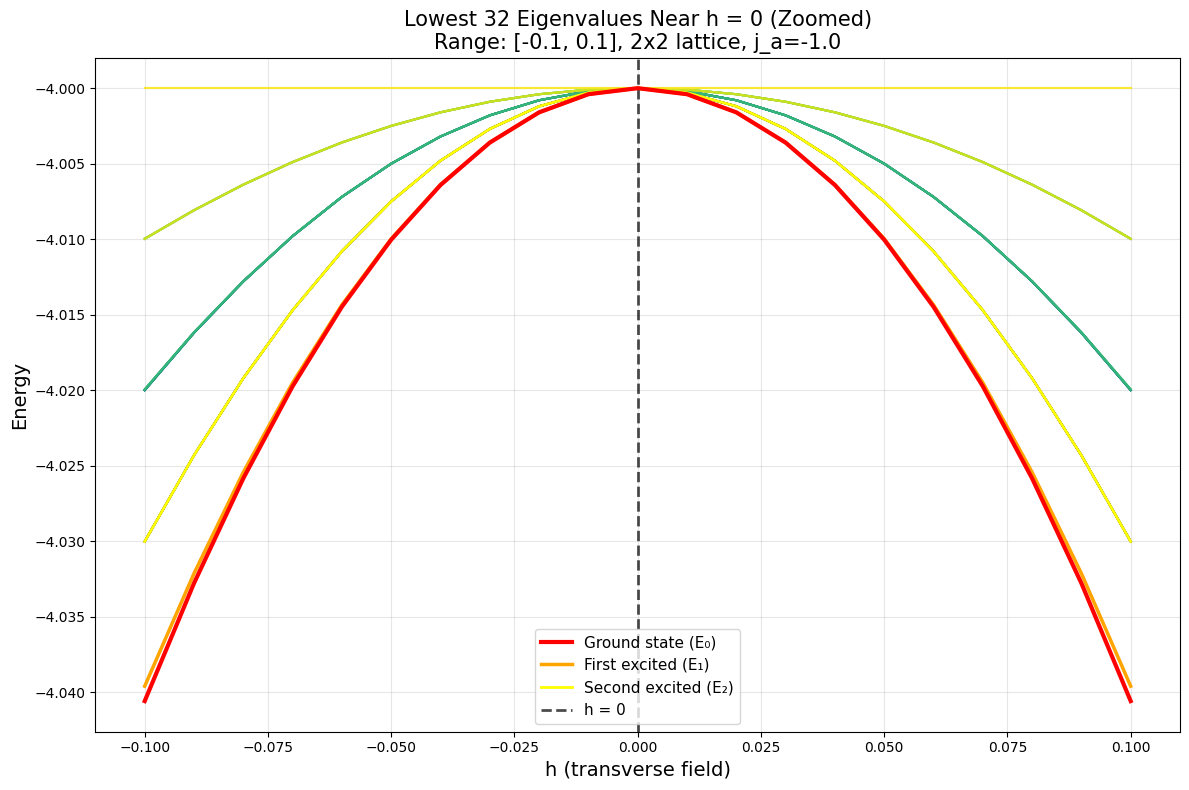

In [30]:
# Zoomed view: lowest 32 eigenvalues in smaller range around h=0
zoom_range = 0.1
mask_zoom = np.abs(h_values_fine) <= zoom_range
h_values_zoom = h_values_fine[mask_zoom]
eigenvalues_zoom = all_eigenvalues_fine[mask_zoom, :]

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot all 32 eigenvalues in zoomed range
colors = plt.cm.viridis(np.linspace(0, 1, n_eigenvalues_to_plot))
for i in range(n_eigenvalues_to_plot):
    ax.plot(h_values_zoom, eigenvalues_zoom[:, i], 
            color=colors[i], linewidth=1.5, alpha=0.7)

# Highlight ground state and first few excited states
ax.plot(h_values_zoom, eigenvalues_zoom[:, 0], 
        'r-', linewidth=3, label='Ground state (E₀)', zorder=10)
ax.plot(h_values_zoom, eigenvalues_zoom[:, 1], 
        'orange', linewidth=2.5, label='First excited (E₁)', zorder=9)
if n_eigenvalues_to_plot > 2:
    ax.plot(h_values_zoom, eigenvalues_zoom[:, 2], 
            'yellow', linewidth=2, label='Second excited (E₂)', zorder=8)

# Mark h=0
ax.axvline(x=0, color='k', linestyle='--', linewidth=2, alpha=0.7, label='h = 0', zorder=5)

ax.set_xlabel('h (transverse field)', fontsize=14)
ax.set_ylabel('Energy', fontsize=14)
ax.set_title(f'Lowest {n_eigenvalues_to_plot} Eigenvalues Near h = 0 (Zoomed)\nRange: [-{zoom_range}, {zoom_range}], {Lx}x{Ly} lattice, j_a={j_a}', fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig('../figures/z2gauge_lowest32_spectrum_near_zero_zoomed.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [31]:
# Summary: Energy values at h=0 for lowest 32 states
h_zero_idx_fine = np.argmin(np.abs(h_values_fine))
h_zero_val_fine = float(h_values_fine[h_zero_idx_fine])
eigenvalues_at_zero = all_eigenvalues_fine[h_zero_idx_fine, :]

print("\n" + "=" * 70)
print(f"LOWEST {n_eigenvalues_to_plot} EIGENVALUES AT h = {h_zero_val_fine:.6f}")
print("=" * 70)
print(f"{'Index':>6} | {'Energy':>15} | {'Gap from GS':>15} | {'Gap from prev':>15}")
print("-" * 70)

for i in range(n_eigenvalues_to_plot):
    energy = eigenvalues_at_zero[i]
    gap_from_gs = energy - eigenvalues_at_zero[0]
    gap_from_prev = energy - eigenvalues_at_zero[i-1] if i > 0 else 0.0
    
    print(f"{i:>6} | {energy:>15.8f} | {gap_from_gs:>15.8f} | {gap_from_prev:>15.8f}")

# Check for degeneracies in the lowest 32 states
print(f"\nDegeneracy analysis (lowest {n_eigenvalues_to_plot} states at h={h_zero_val_fine:.6f}):")
tol = 1e-8
unique_energies, counts = np.unique(np.round(eigenvalues_at_zero / tol) * tol, return_counts=True)

degenerate_levels = []
for energy, count in zip(unique_energies, counts):
    if count > 1:
        degenerate_levels.append((energy, count))

if len(degenerate_levels) > 0:
    print(f"Found {len(degenerate_levels)} degenerate energy levels:")
    print(f"{'Energy':>15} | {'Degeneracy':>12}")
    print("-" * 30)
    for energy, degen in sorted(degenerate_levels):
        print(f"{energy:>15.8f} | {degen:>12}")
else:
    print("No degeneracies found in lowest 32 states (within tolerance).")



LOWEST 32 EIGENVALUES AT h = 0.000000
 Index |          Energy |     Gap from GS |   Gap from prev
----------------------------------------------------------------------
     0 |     -4.00000000 |      0.00000000 |      0.00000000
     1 |     -4.00000000 |      0.00000000 |      0.00000000
     2 |     -4.00000000 |      0.00000000 |      0.00000000
     3 |     -4.00000000 |      0.00000000 |      0.00000000
     4 |     -4.00000000 |      0.00000000 |      0.00000000
     5 |     -4.00000000 |      0.00000000 |      0.00000000
     6 |     -4.00000000 |      0.00000000 |      0.00000000
     7 |     -4.00000000 |      0.00000000 |      0.00000000
     8 |     -4.00000000 |      0.00000000 |      0.00000000
     9 |     -4.00000000 |      0.00000000 |      0.00000000
    10 |     -4.00000000 |      0.00000000 |      0.00000000
    11 |     -4.00000000 |      0.00000000 |      0.00000000
    12 |     -4.00000000 |      0.00000000 |      0.00000000
    13 |     -4.00000000 |      0.00

In [32]:
# Plot lowest 32 eigenvalues from h=-0.5 to h=0 with 50 points
print("\n" + "=" * 70)
print("COMPUTING LOWEST 32 EIGENVALUES: h = -0.5 to 0 (50 points)")
print("=" * 70)

h_start = -0.5
h_end = 0.0
n_points = 50
h_values_range = jnp.linspace(h_start, h_end, n_points)

print(f"Computing lowest 32 eigenvalues for {n_points} h values...")
print(f"Range: [{h_start}, {h_end}]")

eigenvalues_range = []

for i, h in enumerate(h_values_range):
    H = hamiltonian(j_a=j_a, h=h, star_ops=star_ops, trans_ops=trans_ops)
    eigenvalues = jnp.linalg.eigvalsh(H)
    
    # Store only the first 32 eigenvalues
    eigenvalues_subset = eigenvalues[:min(32, len(eigenvalues))]
    eigenvalues_range.append(np.array(eigenvalues_subset))
    
    if (i + 1) % 10 == 0:
        print(f"  Progress: {i+1}/{n_points} - h={float(h):.4f}")

eigenvalues_range = np.array(eigenvalues_range)
print(f"\n✓ Spectrum computation complete!")
print(f"Shape: {eigenvalues_range.shape} (h_values x eigenvalues)")



COMPUTING LOWEST 32 EIGENVALUES: h = -0.5 to 0 (50 points)
Computing lowest 32 eigenvalues for 50 h values...
Range: [-0.5, 0.0]
  Progress: 10/50 - h=-0.4082
  Progress: 20/50 - h=-0.3061
  Progress: 30/50 - h=-0.2041
  Progress: 40/50 - h=-0.1020
  Progress: 50/50 - h=0.0000

✓ Spectrum computation complete!
Shape: (50, 32) (h_values x eigenvalues)


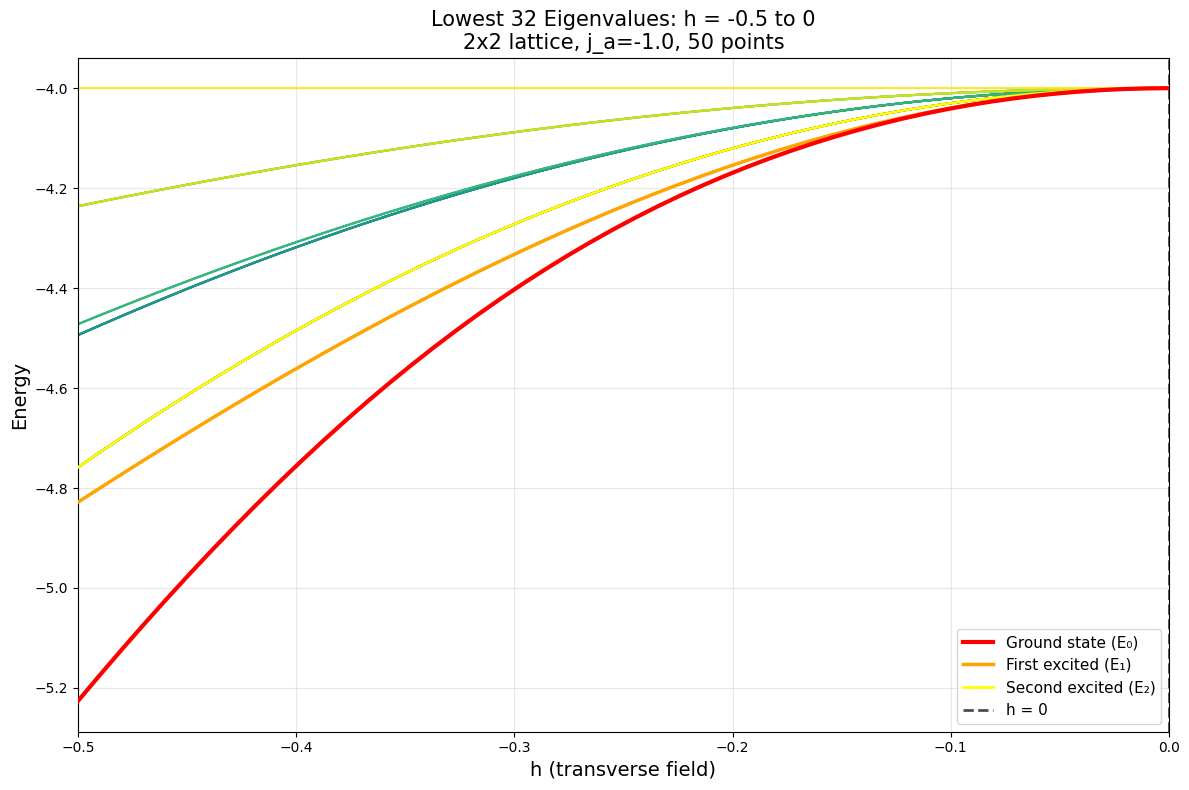

In [33]:
# Plot lowest 32 eigenvalues from h=-0.5 to h=0
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

n_eigenvalues = 32
colors = plt.cm.viridis(np.linspace(0, 1, n_eigenvalues))

# Plot all 32 eigenvalues
for i in range(n_eigenvalues):
    ax.plot(h_values_range, eigenvalues_range[:, i], 
            color=colors[i], linewidth=1.5, alpha=0.7)

# Highlight ground state and first few excited states
ax.plot(h_values_range, eigenvalues_range[:, 0], 
        'r-', linewidth=3, label='Ground state (E₀)', zorder=10)
ax.plot(h_values_range, eigenvalues_range[:, 1], 
        'orange', linewidth=2.5, label='First excited (E₁)', zorder=9)
if n_eigenvalues > 2:
    ax.plot(h_values_range, eigenvalues_range[:, 2], 
            'yellow', linewidth=2, label='Second excited (E₂)', zorder=8)

# Mark h=0
ax.axvline(x=0, color='k', linestyle='--', linewidth=2, alpha=0.7, label='h = 0', zorder=5)

ax.set_xlabel('h (transverse field)', fontsize=14)
ax.set_ylabel('Energy', fontsize=14)
ax.set_title(f'Lowest {n_eigenvalues} Eigenvalues: h = -0.5 to 0\n{Lx}x{Ly} lattice, j_a={j_a}, {n_points} points', fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')
ax.set_xlim(h_start, h_end)

plt.tight_layout()
plt.savefig('../figures/z2gauge_lowest32_spectrum_h-0.5_to_0.pdf', bbox_inches='tight', dpi=150)
plt.show()


In [34]:
# Summary statistics for the range h=-0.5 to 0
print("\n" + "=" * 70)
print("SUMMARY: LOWEST 32 EIGENVALUES FROM h = -0.5 TO 0")
print("=" * 70)

# At h = -0.5
h_start_idx = 0
eigenvalues_at_start = eigenvalues_range[h_start_idx, :]

# At h = 0
h_end_idx = n_points - 1
eigenvalues_at_end = eigenvalues_range[h_end_idx, :]

print(f"\nAt h = {float(h_values_range[h_start_idx]):.4f} (start):")
print(f"  Ground state energy: {eigenvalues_at_start[0]:.8f}")
print(f"  First excited energy: {eigenvalues_at_start[1]:.8f}")
print(f"  Spectral gap: {eigenvalues_at_start[1] - eigenvalues_at_start[0]:.8f}")

print(f"\nAt h = {float(h_values_range[h_end_idx]):.6f} (end):")
print(f"  Ground state energy: {eigenvalues_at_end[0]:.8f}")
print(f"  First excited energy: {eigenvalues_at_end[1]:.8f}")
print(f"  Spectral gap: {eigenvalues_at_end[1] - eigenvalues_at_end[0]:.8f}")

# Energy range
print(f"\nEnergy ranges:")
print(f"  Ground state: [{np.min(eigenvalues_range[:, 0]):.8f}, {np.max(eigenvalues_range[:, 0]):.8f}]")
print(f"  First excited: [{np.min(eigenvalues_range[:, 1]):.8f}, {np.max(eigenvalues_range[:, 1]):.8f}]")
print(f"  32nd state: [{np.min(eigenvalues_range[:, 31]):.8f}, {np.max(eigenvalues_range[:, 31]):.8f}]")



SUMMARY: LOWEST 32 EIGENVALUES FROM h = -0.5 TO 0

At h = -0.5000 (start):
  Ground state energy: -5.22625186
  First excited energy: -4.82842712
  Spectral gap: 0.39782473

At h = 0.000000 (end):
  Ground state energy: -4.00000000
  First excited energy: -4.00000000
  Spectral gap: 0.00000000

Energy ranges:
  Ground state: [-5.22625186, -4.00000000]
  First excited: [-4.82842712, -4.00000000]
  32nd state: [-4.00000000, -4.00000000]


In [27]:
# Summary table
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'h':>8} | {'E₀':>12} | {'E₁':>12} | {'Gap':>12} | {'Gap/E₀':>10}")
print("-" * 70)

# Show values at key points
for idx in [0, len(h_values)//4, len(h_values)//2, 3*len(h_values)//4, len(h_values)-1]:
    h_val = float(h_values[idx])
    e0 = ground_energies[idx]
    e1 = first_excited[idx]
    gap = spectral_gaps[idx]
    gap_ratio = gap / abs(e0) if abs(e0) > 1e-10 else np.nan
    
    print(f"{h_val:>8.3f} | {e0:>12.6f} | {e1:>12.6f} | {gap:>12.8f} | {gap_ratio:>10.6f}")

print("=" * 70)



SUMMARY TABLE
       h |           E₀ |           E₁ |          Gap |     Gap/E₀
----------------------------------------------------------------------
  -2.000 |   -16.255761 |   -12.391556 |   3.86420518 |   0.237713
  -1.510 |   -12.425900 |    -9.594311 |   2.83158967 |   0.227878
  -0.980 |    -8.392819 |    -6.752194 |   1.64062483 |   0.195480
  -0.490 |    -5.173425 |    -4.799714 |   0.37371092 |   0.072237
   0.000 |    -4.000000 |    -4.000000 |   0.00000000 |   0.000000
